# Examen Final — Programación 1 (F12)
## Análisis de Datos Climáticos con la API de Open-Meteo

**Nombre:** Kevin Geovani Méndez Cardona  
**Carnet:** 202506794  
**Fecha:** 11/05/2026  
**Punteo total:** 100 puntos

---

| Ejercicio | Tema | Puntos |
|---|---|:---:|
| 1a | Cargar datos desde la API con `requests` + `pd.DataFrame()` | 10 |
| 1b | Explorar el DataFrame con un ciclo `for` | 10 |
| 2a | Encontrar el día más caluroso con un ciclo `for` | 10 |
| 2b | Top 5 días más lluviosos con pandas | 10 |
| 3a | Función `clasificar_dia()` con condicionales | 15 |
| 3b | Agregar columna de categoría y agrupar con `groupby` | 10 |
| 4a | Función `analizar_clima()` que retorna un diccionario | 15 |
| 4b | Tres visualizaciones con matplotlib/seaborn | 20 |
| | **Total** | **100** |

---

> **Instrucciones generales**
> - Completa cada ejercicio en la celda indicada.
> - Ejecuta las celdas **en orden** de arriba hacia abajo.
> - Puedes consultar tus apuntes y el enunciado del examen en U Virtual.
> - Entrega el notebook con **todas las celdas ejecutadas** (con output visible).
> - Sube el archivo a tu repositorio en GitHub y envía el enlace a U Virtual.


---
## Contexto: el clima de Ciudad de Guatemala

Guatemala tiene un clima subtropical de montaña, con dos estaciones bien definidas:

- **Estación seca** (noviembre – abril): días cálidos, noches frías, precipitación casi nula
- **Estación lluviosa** (mayo – octubre): lluvias frecuentes, temperaturas más estables

Ciudad de Guatemala se ubica a **1 500 m de altitud**, lo que modera las temperaturas
respecto a las zonas costeras.

### Variables climáticas del dataset

| Variable | Unidad | Descripción |
|---|---|---|
| Temperatura máxima | °C | Temperatura más alta registrada en el día |
| Temperatura mínima | °C | Temperatura más baja registrada en el día |
| Precipitación | mm | Agua acumulada en el día (1 mm = 1 L/m²) |
| Viento máximo | km/h | Ráfaga de viento más fuerte del día |

### Clasificación de días por lluvia

| Precipitación | Categoría |
|---|---|
| < 1 mm | Seco |
| 1 – 4.9 mm | Lluvia ligera |
| 5 – 19.9 mm | Lluvia moderada |
| ≥ 20 mm | Lluvia intensa |


---
## El dataset: Open-Meteo Historical Weather

**Fuente:** [open-meteo.com](https://open-meteo.com) — API meteorológica de código abierto,
sin registro ni API key.

Los datos de este examen contienen el **registro climático diario de Ciudad de Guatemala
durante el año 2024** (366 días — 2024 es año bisiesto).

### Cómo cargar los datos

La API devuelve JSON. El código siguiente obtiene los datos y los convierte a DataFrame:

```python
import requests, pandas as pd

URL = (
    "https://archive-api.open-meteo.com/v1/archive"
    "?latitude=14.64&longitude=-90.51"
    "&start_date=2024-01-01&end_date=2024-12-31"
    "&daily=temperature_2m_max,temperature_2m_min"
    ",precipitation_sum,wind_speed_10m_max"
    "&timezone=America%2FGuatemala"
)

respuesta = requests.get(URL)
datos     = respuesta.json()
clima     = pd.DataFrame(datos['daily'])
clima['time'] = pd.to_datetime(clima['time'])
```

### Columnas del DataFrame resultante

| Columna | Tipo | Descripción |
|---|---|---|
| `time` | datetime | Fecha del registro |
| `temperature_2m_max` | float | Temperatura máxima diaria (°C) |
| `temperature_2m_min` | float | Temperatura mínima diaria (°C) |
| `precipitation_sum` | float | Precipitación acumulada diaria (mm) |
| `wind_speed_10m_max` | float | Velocidad máxima del viento (km/h) |


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

URL_CLIMA = (
    "https://archive-api.open-meteo.com/v1/archive"
    "?latitude=14.64&longitude=-90.51"
    "&start_date=2024-01-01&end_date=2024-12-31"
    "&daily=temperature_2m_max,temperature_2m_min"
    ",precipitation_sum,wind_speed_10m_max"
    "&timezone=America%2FGuatemala"
)

print("Librerias importadas correctamente.")


Librerias importadas correctamente.


---
## Identificación del estudiante

Completa tu nombre y carnet en la siguiente celda y **ejecútala antes de comenzar**.


In [2]:
# Completa tus datos
NOMBRE = "Kevin Geovani Méndez Cardona"   # TU NOMBRE AQUI
CARNET = "202506794"         # TU CARNET AQUI

if NOMBRE == "Nombre Apellido" or CARNET == "202300000":
    raise ValueError("Completa tu nombre y carnet antes de continuar.")

print(f"Estudiante : {NOMBRE}")
print(f"Carnet     : {CARNET}")


Estudiante : Kevin Geovani Méndez Cardona
Carnet     : 202506794


---
## Ejercicio 1 — Cargar y explorar los datos (20 pts)

### Parte a) — Cargar datos desde la API (10 pts)

La API de Open-Meteo devuelve JSON. Para convertirlo a DataFrame:
1. Usa `requests.get(URL_CLIMA)` para obtener la respuesta
2. Verifica que fue exitosa (`respuesta.ok`)
3. Convierte a diccionario con `.json()`
4. Crea el DataFrame con `pd.DataFrame(datos['daily'])`
5. Convierte la columna `time` a fecha con `pd.to_datetime()`

Guarda el resultado en la variable `clima`.
Luego muestra `.head()`, `.shape`, `.dtypes` y `.isnull().sum()`.

### ¿Por qué verificar la respuesta antes de parsear?

Si el servidor devuelve un error (ej. código 503), el cuerpo de la respuesta
no contiene JSON válido. Llamar `.json()` sin verificar causaría un error.
Siempre verifica `respuesta.ok` antes de continuar.


In [3]:
# Realiza la petición HTTP
respuesta = requests.get(URL_CLIMA, timeout=15)

# Verifica que fue exitosa
if not respuesta.ok:
    print(f"Error {respuesta.status_code}: {respuesta.text[:200]}")
    raise SystemExit("No se pudieron obtener los datos. Intenta de nuevo.")

# Convierte la respuesta a diccionario
datos = respuesta.json()

# Crea el DataFrame desde datos['daily'] y convierte 'time' a datetime
clima =  pd.DataFrame(datos['daily'])
clima['time'] = pd.to_datetime(clima['time'])

print(f"Datos cargados: {len(clima)} dias")

# Muestra head(), shape, dtypes e isnull().sum()
print(f"\nForma: {clima.shape}")
print(f"\nTipo:\n{clima.dtypes}")
print(f"\nTotal de valores nulos:\n{clima.isnull().sum()}")


Datos cargados: 366 dias

Forma: (366, 5)

Tipo:
time                  datetime64[us]
temperature_2m_max           float64
temperature_2m_min           float64
precipitation_sum            float64
wind_speed_10m_max           float64
dtype: object

Total de valores nulos:
time                  0
temperature_2m_max    0
temperature_2m_min    0
precipitation_sum     0
wind_speed_10m_max    0
dtype: int64


### Parte b) — Explorar con un ciclo `for` (10 pts)

Usando un ciclo `for` y `.iterrows()`, imprime la información de los
**primeros 5 días** en este formato:

```
Día 1: 2024-01-01 | max=23.8°C | min=10.7°C | lluvia=0.0 mm
Día 2: 2024-01-02 | max=24.1°C | min=13.1°C | lluvia=0.2 mm
...
```

> Para mostrar la fecha sin la hora puedes usar `fila['time'].date()`.


In [4]:
# Hint: .iterrows() devuelve pares (indice, fila)
# Hint: fila['time'].date() da solo la parte de fecha (sin hora)

contador = 0
for indice, fila in clima.iterrows():
    if contador >= 5:
        break
    print(f"Día {contador + 1}: {fila['time'].date()} | max={fila['temperature_2m_max']}°C | min={fila['temperature_2m_min']}°C | lluvia={fila['precipitation_sum']} mm")

    contador += 1


Día 1: 2024-01-01 | max=23.8°C | min=10.7°C | lluvia=0.0 mm
Día 2: 2024-01-02 | max=24.1°C | min=13.1°C | lluvia=0.2 mm
Día 3: 2024-01-03 | max=27.5°C | min=12.8°C | lluvia=0.1 mm
Día 4: 2024-01-04 | max=24.0°C | min=13.9°C | lluvia=0.0 mm
Día 5: 2024-01-05 | max=26.5°C | min=11.9°C | lluvia=0.0 mm


---
## Ejercicio 2 — Encontrar los extremos (20 pts)

### Parte a) — Día más caluroso con ciclo `for` (10 pts)

Usando **únicamente** un ciclo `for` y un `if`, itera sobre la columna
`temperature_2m_max` y encuentra el día con la **temperatura máxima más alta**.
Guarda el índice y la temperatura máxima encontrada, luego imprime la fecha,
temperatura máxima, mínima y precipitación de ese día.

### Parte b) — Top 5 más lluviosos con pandas (10 pts)

Usa `.sort_values()` + `.head()` para encontrar los **5 días con mayor precipitación**.
Muestra las columnas `time`, `precipitation_sum`, `temperature_2m_max`
y `temperature_2m_min`.
Luego verifica que el día encontrado en Parte a) aparece en el top 5 de temperaturas.


In [5]:
# ── Parte a) — ciclo for ─────────────────────────────────────────────────────
# Hint: necesitas dos variables auxiliares:
#   temp_max   = 0     (para ir guardando la mayor temperatura encontrada)
#   idx_max    = None  (para recordar el índice de esa fila)

temp_max = 0
idx_max  = None

for idx, temp in enumerate(clima['temperature_2m_max']):
    if temp > temp_max:
        temp_max = temp
        idx_max = idx


print("Dia mas caluroso:")
print(clima.loc[idx_max, ['time','temperature_2m_max','temperature_2m_min','precipitation_sum']])

# ── Parte b) — pandas ─────────────────────────────────────────────────────────
print("\nTop 5 dias mas lluviosos:")
print(clima.sort_values('precipitation_sum', ascending=False)[['time', 'precipitation_sum', 'temperature_2m_max', 'temperature_2m_min']].head(5))

print("\nTop 5 dias mas calurosos:")
print(clima.sort_values('temperature_2m_max', ascending=False)[['time', 'precipitation_sum', 'temperature_2m_max', 'temperature_2m_min']].head(5))


Dia mas caluroso:
time                  2024-05-07 00:00:00
temperature_2m_max                   33.3
temperature_2m_min                   15.1
precipitation_sum                     0.0
Name: 127, dtype: object

Top 5 dias mas lluviosos:
          time  precipitation_sum  temperature_2m_max  temperature_2m_min
168 2024-06-17               64.6                19.4                16.4
293 2024-10-20               46.3                21.5                16.5
169 2024-06-18               40.7                21.2                16.1
174 2024-06-23               40.6                23.3                17.1
171 2024-06-20               31.1                19.4                16.6

Top 5 dias mas calurosos:
          time  precipitation_sum  temperature_2m_max  temperature_2m_min
127 2024-05-07                0.0                33.3                15.1
124 2024-05-04                0.0                32.7                15.4
123 2024-05-03                0.0                32.4                

#### Preguntas de interpretación — Ejercicio 2

Responde usando los valores **exactos** que obtuviste al ejecutar las celdas anteriores.

1. **¿Cuántos días tiene tu dataset?** 366  
   **¿Cuál fue la temperatura máxima más alta del año?** 33.3 °C  
   **¿En qué fecha ocurrió?** 7 de mayo

2. **¿Cuál fue el día más lluvioso?**  
   Fecha: 17 de junio | Precipitación: 64.6 mm | Temperatura máxima ese día: 19.4 °C  
   ¿En qué estación del año ocurrió (seca o lluviosa)? lluviosa  
   ¿Tiene sentido según el contexto climático de Guatemala? Justifica.

   *Tu respuesta:* Si tiene sentido, este día se encuentra dentro de la temporada más intensa de lluvia para el país (de mayo a octubre), por lo que coincide con los datos otorgados.

3. ¿El día más caluroso y el más lluvioso coinciden?  
   ¿Qué te dice eso sobre la relación entre temperatura y precipitación en Guatemala?

   *Tu respuesta:* El día más caluroso no coincide con el más lluvioso, el más caluroso corresponde al 7 de mayo y el más lluvioso al 17 de junio. Varios de los días más calurosos fueron a inicios de mayo, pues fueron justo antes de que empezara la temporada de mayor lluvia. Durante los días calurosos es cielo se mantiene despejado, permitiendo una mayor radiación solar que eleva la temperatura, por el contrario en los días lluviosos el cielo esta nublado y la precipitación aumenta, por lo que podemos intuir que existe una relación entre la temperatura y la precipitación que está estrechamente ligada a las nubes.


---
## Ejercicio 3 — Clasificar días con condicionales (25 pts)

### Parte a) — Función `clasificar_dia(precip)` (15 pts)

Escribe una función que reciba la precipitación diaria (float, en mm)
y retorne la categoría según la siguiente escala:

| Precipitación (mm) | Categoría |
|---|---|
| precip < 1 | `'Seco'` |
| 1 ≤ precip < 5 | `'Lluvia ligera'` |
| 5 ≤ precip < 20 | `'Lluvia moderada'` |
| precip ≥ 20 | `'Lluvia intensa'` |

### Parte b) — Aplicar y agrupar (10 pts)

Usa tu función para agregar la columna `'tipo_dia'` al DataFrame `clima`.
Luego usa `.groupby('tipo_dia')` para contar cuántos días hay de cada tipo
e imprime el resultado.


In [6]:
# ── Parte a) — función con condicionales ─────────────────────────────────────
# Hint: usa if / elif / elif / else

def clasificar_dia(precip):
    """Clasifica un dia segun su precipitacion."""
    if precip < 1:
        return 'Seco'
    elif precip < 5:
        return 'Lluvia ligera'
    elif precip < 20:
        return 'Lluvia moderada'
    else:
        return 'Lluvia intensa'
        pass


# Prueba tu función — verifica que los resultados son correctos:
for p in [0.0, 0.5, 1.0, 3.5, 5.0, 15.0, 20.0, 45.2]:
    print(f"  precip={p:5.1f} mm  →  {clasificar_dia(p)}")

# ── Parte b) — agregar columna y agrupar ─────────────────────────────────────
# Hint: aplica la función con .apply()

clima['tipo_dia'] = clima['precipitation_sum'].apply(clasificar_dia)

tiposdd = clima.groupby('tipo_dia')['tipo_dia'].count()
print(f'\n{tiposdd}')
print('\nPorcentaje de cada tipo')
porcentaje = tiposdd / tiposdd.sum() * 100
print(porcentaje.round(1))

  precip=  0.0 mm  →  Seco
  precip=  0.5 mm  →  Seco
  precip=  1.0 mm  →  Lluvia ligera
  precip=  3.5 mm  →  Lluvia ligera
  precip=  5.0 mm  →  Lluvia moderada
  precip= 15.0 mm  →  Lluvia moderada
  precip= 20.0 mm  →  Lluvia intensa
  precip= 45.2 mm  →  Lluvia intensa

tipo_dia
Lluvia intensa      16
Lluvia ligera       88
Lluvia moderada     59
Seco               203
Name: tipo_dia, dtype: int64

Porcentaje de cada tipo
tipo_dia
Lluvia intensa      4.4
Lluvia ligera      24.0
Lluvia moderada    16.1
Seco               55.5
Name: tipo_dia, dtype: float64


#### Preguntas de interpretación — Ejercicio 3

1. Según los resultados de `value_counts()`, completa la tabla:

   | Categoría | Cantidad de días | % del año |
   |---|---|---|
   | Seco | 203 | 55.5 % |
   | Lluvia ligera | 88 | 24 % |
   | Lluvia moderada | 59 | 16.1 % |
   | Lluvia intensa | 16 | 4.4 % |

2. ¿Qué tipo de día predomina en Guatemala durante 2024?
   ¿Coincide con lo que esperarías dado que tiene estación seca y lluviosa?

   *Tu respuesta:* El tipo de día predominante es seco, con un 55.5% del año en total. Esto se bastante coincidente con el contexto climático de Guatemala, ya que cada temporada tiene aproximadamente 6 meses.

3. ¿Cuántos días de `'Lluvia intensa'` (≥ 20 mm) hubo?
   ¿En qué meses esperarías que se concentren? ¿Por qué?

   *Tu respuesta:* Hubo 16 días de lluvia intensa en todo el año, representando apenas el 4.4% de este. 4 de los 5 días más lluviosos  ocurrieron en junio y uno en octubre. Es de esperar que estos 16 días se concentren principalmente en junio, julio, septiembre y octubre, que son los meses más activos de la época lluviosa en Guatemala.


---
## Ejercicio 4 — Análisis completo y visualizaciones (35 pts)

### Parte a) — Función `analizar_clima(df)` (15 pts)

Escribe una función que reciba el DataFrame `clima` y retorne un **diccionario**
con las siguientes claves:

| Clave | Valor esperado |
|---|---|
| `'total_dias'` | número total de días en el dataset |
| `'temp_media'` | temperatura máxima promedio del año (redondeada a 1 decimal) |
| `'temp_record'` | temperatura máxima absoluta del año |
| `'precip_total'` | precipitación total acumulada en el año (mm) |
| `'dias_lluviosos'` | días con precipitación ≥ 5 mm |
| `'mes_mas_caliente'` | número del mes con mayor temperatura máxima promedio |

Luego llama la función con `clima` e imprime cada clave y su valor.

### Parte b) — Visualizaciones (20 pts)

Crea **3 gráficas**. Cada una debe tener título y etiquetas en ambos ejes:

1. **Serie de tiempo**: temperatura máxima mensual promedio a lo largo del año
   (agrupa por mes con `.groupby()` y grafica con `plt.plot()` o `sns.lineplot()`)
2. **Scatter plot**: temperatura máxima (`temperature_2m_max`) vs precipitación
   (`precipitation_sum`), coloreado por `tipo_dia` (usa `hue='tipo_dia'`)
3. **Histograma** de precipitación diaria (usa al menos 20 intervalos)


In [7]:
# ── Parte a) — función de análisis ───────────────────────────────────────────
# Hint: usa .mean(), .max(), .sum() sobre las columnas del DataFrame
# Hint: para 'dias_lluviosos' puedes usar (df['precipitation_sum'] >= 5).sum()
#       o un ciclo for con condicional
# Hint: para 'mes_mas_caliente' agrega una columna 'mes' con df['time'].dt.month
#       luego groupby('mes')['temperature_2m_max'].mean().idxmax()

def analizar_clima(df):
    """
    Resume las estadísticas principales del dataset climático.

    Parámetro:
        df (DataFrame): el DataFrame de datos climáticos diarios.

    Retorna:
        dict con las claves: total_dias, temp_media, temp_record,
                             precip_total, dias_lluviosos, mes_mas_caliente.
    """
    df['mes'] = df['time'].dt.month

    resultado = {
        "total_dias":       len(df),
        "temp_media":       round(df['temperature_2m_max'].mean(), 1),
        "temp_record":      df['temperature_2m_max'].max(),
        "precip_total":     df['precipitation_sum'].sum(),
        "dias_lluviosos":   (df['precipitation_sum'] >= 5).sum(),
        "mes_mas_caliente": df.groupby('mes')['temperature_2m_max'].mean().idxmax()
    }
    return resultado


# Llama la función e imprime el resumen
resumen = analizar_clima(clima)
for clave, valor in resumen.items():
    print(f"  {clave:<22}: {valor}")


  total_dias            : 366
  temp_media            : 25.8
  temp_record           : 33.3
  precip_total          : 1386.6
  dias_lluviosos        : 75
  mes_mas_caliente      : 5


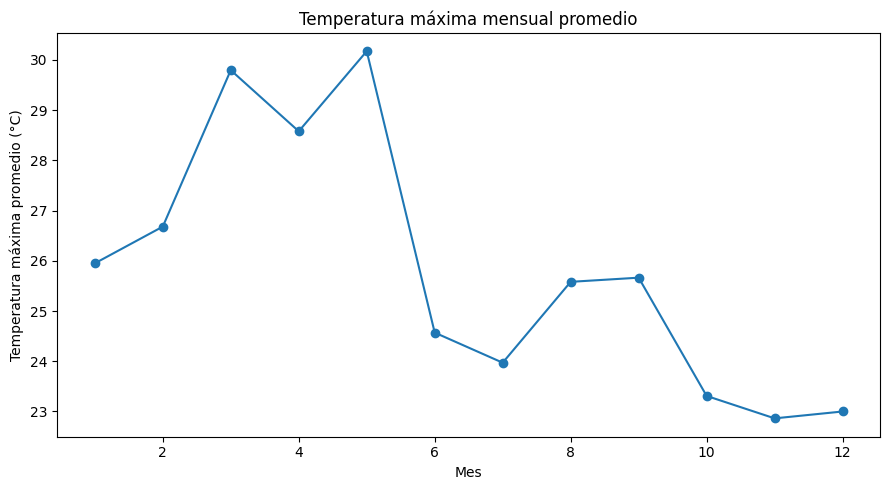

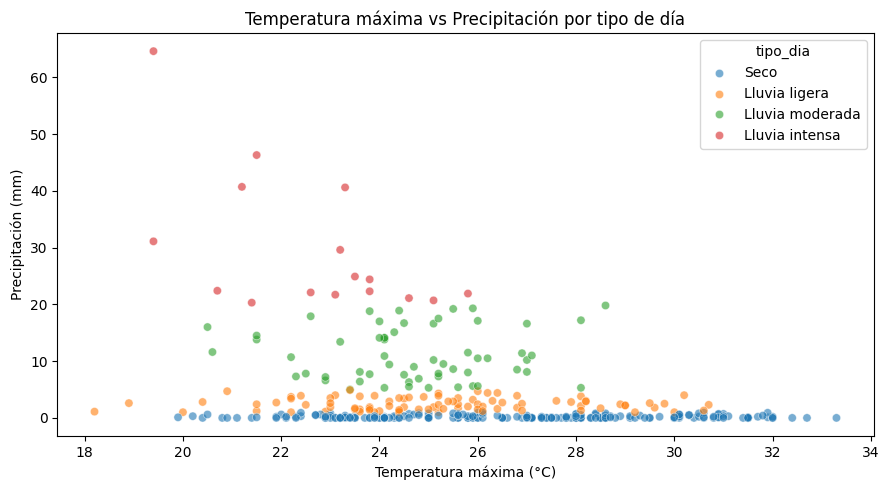

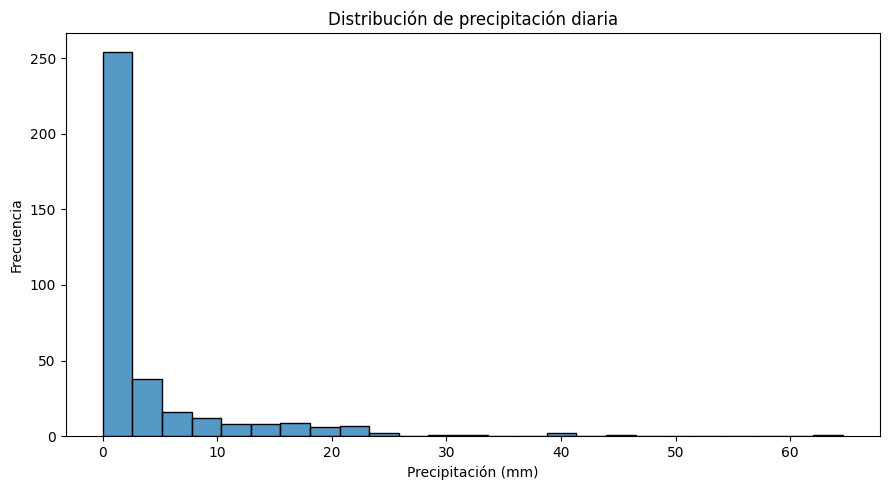

In [8]:
# ── Parte b) — Visualizaciones ───────────────────────────────────────────────
# Gráfica 1: temperatura máxima mensual promedio (serie de tiempo)
plt.figure(figsize=(9, 5))
# Hint: agrega columna 'mes' y agrupa:
clima['mes'] = clima['time'].dt.month
temp_mensual = clima.groupby('mes')['temperature_2m_max'].mean()
plt.plot(temp_mensual.index, temp_mensual.values, marker='o')

plt.title("Temperatura máxima mensual promedio")
plt.xlabel("Mes")
plt.ylabel("Temperatura máxima promedio (°C)")
plt.tight_layout()
plt.show()

# Gráfica 2: scatter temperatura vs precipitación coloreado por tipo_dia
plt.figure(figsize=(9, 5))
sns.scatterplot(data=clima, x='temperature_2m_max', y='precipitation_sum', hue='tipo_dia', alpha=0.6)
                       
plt.title("Temperatura máxima vs Precipitación por tipo de día")
plt.xlabel("Temperatura máxima (°C)")
plt.ylabel("Precipitación (mm)")
plt.tight_layout()
plt.show()


# Gráfica 3: histograma de precipitación diaria
plt.figure(figsize=(9, 5))
sns.histplot(data=clima, x='precipitation_sum', bins=25)

plt.title("Distribución de precipitación diaria")
plt.xlabel("Precipitación (mm)")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()


#### Preguntas de interpretación — Ejercicio 4

1. Según la función `analizar_clima()`, completa:
   - Temperatura máxima media anual: 25.8 °C  
   - Temperatura máxima record: 33.3 °C  
   - Precipitación total anual: 1386.6 mm  
   - Días lluviosos (≥ 5 mm): 75  
   - Mes más caliente: Mayo

2. **Sobre la serie de tiempo (Gráfica 1):**  
   ¿En qué meses la temperatura fue más alta? ¿Y más baja?
   ¿Puedes distinguir las dos estaciones en la gráfica? Descríbelo.

   *Tu respuesta:* Los meses más calurosos fueron marzo, abril y mayo. Los meses más fríos fueron junio, julio y agosto, que coinciden con el núcleo de la época lluviosa. Sí se pueden distinguir las dos estaciones: la época seca muestra temperaturas en ascenso progresivo, mientras que la época lluviosa muestra una caída notable de temperatura que se mantiene estable y baja hasta que las lluvias terminan.


3. **Sobre el scatter plot (Gráfica 2):**  
   ¿Los días de `'Lluvia intensa'` tienden a tener temperaturas más altas o más bajas?
   ¿Qué relación general observas entre temperatura y precipitación?

   *Tu respuesta:* Los días de lluvia intensa tienden a tener temperaturas más bajas, generalmente entre 18 y 24 °C. Los días secos se agrupan en las temperaturas más altas, mientras que los días lluviosos se desplazan hacia la izquierda de la gráfica.


5. **Sobre el histograma de precipitación (Gráfica 3):**  
   ¿La distribución es simétrica? ¿Qué rango de precipitación ocurre con mayor frecuencia?
   ¿Por qué tiene sentido que la mayoría de los días tengan precipitación cercana a cero?

   *Tu respuesta:* La distribución no es simétrica, la mayoría de los días al inicio tienen precipitación cercana a cero. Esto tiene sentido porque Guatemala tiene aproximadamente 6 meses de época seca donde casi no llueve, generando una gran acumulación de días con 0 mm. Los días con lluvia intensa son eventos menos frecuentes, lo que se ve reflejado con su menor presencia en la gráfica.

---
## Ejercicio 5 — Programación Orientada a Objetos (25 pts)

En el archivo `poo_clima.py` encontrarás tres clases:

- **`RegistroMeteorologico`** — clase base con atributo común: `fecha`
- **`DiaClimatico`** — hereda de `RegistroMeteorologico`, agrega `temp_max`, `temp_min`, `precipitacion` y `viento_max`
- **`RegistroAnual`** — colección de objetos `DiaClimatico` con métodos de consulta

**Paso 1:** Abre `poo_clima.py` e implementa todos los métodos marcados con `# TU CÓDIGO AQUÍ`.  
**Paso 2:** Regresa aquí y ejecuta las celdas siguientes en orden.

| Parte | Tarea | Pts |
|---|---|:---:|
| a | 5 métodos de `DiaClimatico`: `rango_termico`, `temp_media`, `es_caluroso`, `clasificar`, `descripcion` | 10 |
| b | 3 métodos de `RegistroAnual`: `dia_mas_caluroso`, `dias_por_tipo`, `temp_promedio_anual`, `resumen` | 10 |
| c | Ejecutar y responder las preguntas de interpretación | 5 |
| | **Subtotal** | **25** |

In [9]:
from poo_clima import DiaClimatico, RegistroAnual

# Construir el registro anual con todos los días del DataFrame
registro = RegistroAnual("Ciudad de Guatemala", 2024)

for indice, fila in clima.iterrows():
    d = DiaClimatico(
        fecha         = fila['time'].date(),
        temp_max      = fila['temperature_2m_max'],
        temp_min      = fila['temperature_2m_min'],
        precipitacion = fila['precipitation_sum'],
        viento_max    = fila['wind_speed_10m_max'],
    )
    registro.agregar_dia(d)

print(f"Registro creado con {len(registro)} días.\n")

# Muestra los primeros 3 usando __str__ (llama internamente a descripcion())
print("Primeros 3 días:")
for dia in registro._dias[:3]:
    print(" ", dia)

Registro creado con 366 días.

Primeros 3 días:
  2024-01-01 | max=23.8°C  min=10.7°C | Seco | Viento: 15.9 km/h
  2024-01-02 | max=24.1°C  min=13.1°C | Seco | Viento: 18.0 km/h
  2024-01-03 | max=27.5°C  min=12.8°C | Seco | Viento: 18.5 km/h


In [10]:
# Día más caluroso del año
mas_caluroso = registro.dia_mas_caluroso()
print("Día más caluroso del año:")
print(" ", mas_caluroso)
print(f"  Rango térmico : {mas_caluroso.rango_termico():.1f} °C")
print(f"  Temperatura media: {mas_caluroso.temp_media():.1f} °C\n")

# Filtrar por tipo
dias_intensos = registro.dias_por_tipo('Lluvia intensa')
print(f"Días de 'Lluvia intensa' en el año: {len(dias_intensos)}\n")

# Resumen completo
registro.resumen()

Día más caluroso del año:
  2024-05-07 | max=33.3°C  min=15.1°C | Seco | Viento: 23.4 km/h
  Rango térmico : 18.2 °C
  Temperatura media: 24.2 °C

Días de 'Lluvia intensa' en el año: 16

Ciudad: Ciudad de Guatemala | Año: 2024 | Total días: 366
Día más caluroso: 2024-05-07 | max=33.3°C  min=15.1°C | Seco | Viento: 23.4 km/h
Temperatura máxima promedio: 25.8°C

Días por tipo:
  Seco                : 203 días
  Lluvia ligera       : 88 días
  Lluvia moderada     : 59 días
  Lluvia intensa      : 16 días


In [11]:
# Verificación: clasificar() debe coincidir con la columna 'tipo_dia' del Ejercicio 3.
print("Verificación POO vs. pandas (primeros 10 días):")
print(f"  {'fecha':>12}  {'precip':>7}  {'pandas Ej.3':>15}  {'POO clasificar()':>16}  {'':>4}")
print("  " + "─" * 64)

for i, (indice, fila) in enumerate(clima.head(10).iterrows()):
    d = DiaClimatico(fila['time'].date(), fila['temperature_2m_max'],
                     fila['temperature_2m_min'], fila['precipitation_sum'],
                     fila['wind_speed_10m_max'])
    cat_poo    = d.clasificar()
    cat_pandas = fila['tipo_dia']
    marca = "✓" if cat_poo == cat_pandas else "✗ REVISAR"
    print(f"  {str(fila['time'].date()):>12}  {fila['precipitation_sum']:>7.1f}  "
          f"{cat_pandas:>15}  {cat_poo:>16}  {marca}")

Verificación POO vs. pandas (primeros 10 días):
         fecha   precip      pandas Ej.3  POO clasificar()      
  ────────────────────────────────────────────────────────────────
    2024-01-01      0.0             Seco              Seco  ✓
    2024-01-02      0.2             Seco              Seco  ✓
    2024-01-03      0.1             Seco              Seco  ✓
    2024-01-04      0.0             Seco              Seco  ✓
    2024-01-05      0.0             Seco              Seco  ✓
    2024-01-06      0.0             Seco              Seco  ✓
    2024-01-07      0.0             Seco              Seco  ✓
    2024-01-08      0.0             Seco              Seco  ✓
    2024-01-09      0.0             Seco              Seco  ✓
    2024-01-10      0.0             Seco              Seco  ✓


#### Preguntas de interpretación — Ejercicio 5

1. ¿Qué diferencia hay entre `RegistroMeteorologico` y `DiaClimatico`?
   ¿Por qué `DiaClimatico.__init__` llama a `super().__init__(fecha)`?

   *Tu respuesta:* `RegistroMeteorologico` es la clase base que define solo el atributo común fecha y los métodos generales `clasificar()` y `descripcion()` sin implementación concreta. `DiaClimatico` hereda de ella y la especializa agregando atributos propios e implementando los métodos con lógica real. `DiaClimatico.__init__` llama a `super().__init__(fecha)` para que la clase padre inicialice el atributo fecha, evitando repetir esa línea en la clase hija.

2. El método `clasificar()` de `DiaClimatico` usa la misma lógica que la función
   `clasificar_dia()` del Ejercicio 3. ¿Qué ventaja tiene implementarlo
   como método de una clase en lugar de como función suelta?

   *Tu respuesta:* Al estar dentro de la clase, `clasificar()` accede directamente a `self.precipitacion` sin necesitar que se le pase como argumento, y queda vinculado al objeto que representa. Además puede reutilizarse desde otros métodos de la misma clase como `descripcion()`, y cualquier objeto `DiaClimatico` lo tiene disponible automáticamente sin necesidad de importar o recordar el nombre de una función externa.


3. Según `registro.resumen()`:
   - ¿En qué fecha fue el día más caluroso? 7 de mayo
   - ¿Cuántos días de `'Lluvia intensa'` hubo en el año? 16
   - Temperatura máxima promedio anual: 25.8 °C

   *Tu respuesta:*

Día más caluroso: 7 de mayo
Días de lluvia intensa: 16
Temperatura máxima promedio anual: 25.8 °C



5. ¿Todos los `✓` aparecen en la celda de verificación?
   Si alguno muestra `✗`, ¿qué parte de tu método `clasificar()` necesita corrección?

   *Tu respuesta:* Aparecen todos los `✓` 

---
## Pregunta final — Conclusiones (incluida en el punteo del Ejercicio 4)

Basándote en los datos analizados, escribe en la celda de abajo una conclusión
en tus propias palabras. Puedes guiarte con estas preguntas:

- ¿En qué meses fue más caluroso/lluvioso el año 2024 en Guatemala?
  ¿Coincide con lo que esperarías de las estaciones seca y lluviosa?
- ¿Qué tipo de día (`tipo_dia`) predominó durante el año?
- ¿Qué relación observas entre temperatura y precipitación en el scatter plot?


---
## Conclusión final

Basándote en **todos los valores que obtuviste** a lo largo del examen,
escribe un párrafo de al menos 5 oraciones que responda:

- ¿Cómo fue el clima de Ciudad de Guatemala durante 2024 según tu análisis?
- ¿Qué patrones estacionales puedes identificar en los datos?
- ¿Qué ventaja tiene usar pandas y NumPy sobre un ciclo `for` manual
  para este tipo de análisis? Da un ejemplo concreto de tu examen.

El clima de Ciudad de Guatemala durante 2024 siguió fielmente el patrón de sus dos estaciones bien definidas. Los meses de marzo, abril y mayo concentraron las temperaturas más altas, alcanzando un récord de 33.3 °C el 7 de mayo, mientras que durante la época lluviosa se observa una caída notable de temperaturas, y 75 días lluviosos registrados, con junio como el mes más intenso en precipitación. El tipo de día predominante fue "Seco" con 203 días, lo cual es consistente con los 6 meses de época seca donde la precipitación es casi nula.
El scatter plot reveló una relación inversa clara entre temperatura y precipitación: los días más calurosos tuvieron precipitación de 0 mm, mientras que los días de lluvia intensa se mantuvieron entre 18 y 24 °C. La diferencia entre Pandas y Numpy comparados con ciclos `for` es notable tanto en legibilidad como en eficiencia, por ejemplo, calcular el promedio de temperatura del año con Pandas se reduce a una sola línea, mientras que con un `for` manual requiere acumular una suma y dividir al final, como en `temp_promedio_anual()`. Para operaciones sobre miles de datos, Pandas ejecuta esas operaciones de forma vectorizada internamente, lo que es considerablemente más rápido que iterar fila por fila.



---
## Sello de entrega

Ejecuta la siguiente celda **como último paso**, justo antes de guardar y subir el notebook.

Registra la posición de la ISS en el momento exacto de tu entrega.
Dado que la ISS se desplaza ~7.7 km/s, dos estudiantes que entreguen
en momentos distintos obtendrán coordenadas completamente diferentes.

> Este sello es **único e irrepetible**: queda vinculado a tu carnet
> y al instante exacto en que ejecutaste la celda.


In [12]:
import requests as _req
from datetime import datetime, timezone

print("Consultando posicion de la ISS...")
try:
    r_iss  = _req.get("http://api.open-notify.org/iss-now.json", timeout=8)
    r_iss.raise_for_status()
    iss    = r_iss.json()
    iss_lat  = float(iss["iss_position"]["latitude"])
    iss_lon  = float(iss["iss_position"]["longitude"])
    iss_hora = datetime.fromtimestamp(iss["timestamp"], tz=timezone.utc).strftime("%Y-%m-%d %H:%M:%S UTC")
    iss_ok   = True
except Exception as e:
    iss_lat, iss_lon, iss_hora = 0.0, 0.0, "no disponible"
    iss_ok = False
    print(f"  Advertencia: sin datos ISS ({e})")

ts = datetime.now(tz=timezone.utc).strftime("%Y-%m-%d %H:%M:%S UTC")

print()
print("=" * 55)
print("        SELLO DE ENTREGA -- EXAMEN FINAL B")
print("=" * 55)
print(f"  Estudiante   : {NOMBRE}")
print(f"  Carnet       : {CARNET}")
print(f"  Fecha/Hora   : {ts}")
print(f"  ISS Latitud  : {iss_lat:+.4f} deg")
print(f"  ISS Longitud : {iss_lon:+.4f} deg")
print(f"  ISS Hora UTC : {iss_hora}")
print("=" * 55)


Consultando posicion de la ISS...

        SELLO DE ENTREGA -- EXAMEN FINAL B
  Estudiante   : Kevin Geovani Méndez Cardona
  Carnet       : 202506794
  Fecha/Hora   : 2026-05-19 04:23:52 UTC
  ISS Latitud  : +47.7434 deg
  ISS Longitud : -99.9365 deg
  ISS Hora UTC : 2026-05-19 04:23:52 UTC


---
## Entrega

1. Ejecuta la celda **Sello de entrega** (arriba)
2. Guarda el notebook: **Archivo → Guardar** (o `Ctrl+S`)
3. Verifica que **todas las celdas tienen output** (ejecuta: **Kernel → Restart & Run All**)
4. Sube el archivo a tu repositorio en GitHub
5. Envía el enlace del notebook en el campo de entrega de **U Virtual**

> **Ruta esperada en tu repositorio:**  
> `examenes/python/examen_final/examen_final.ipynb`
